# BWM session overview — extra sessions highlighted

Rebuilds the mouse × session overview plot from `Video and wheel/Video QC/biasedChoiceWorld/data_check.ipynb` (mice stacked vertically, one colored square per session, colored by task protocol / training status), then overlays the sessions already queued for the extra-BWM design-matrix pipeline (see `paper-individuality/segmentation/2_design_matrix.ipynb`).

Does not modify either source notebook. Only mice that already have a BWM recording (`brainwidemap.bwm_query()`) are shown — same scope as the original overview plot.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgb
from dateutil import parser
from datetime import datetime

prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

# Cached per-mouse session table already saved by data_check.ipynb (same columns:
# task_protocol, session_start_time, session, training_status, session_number, subject).
# Loading it skips ~150 ONE downloads; flip to False to force a live re-query.
USE_CACHED_SESSIONS = True
cache_path = prefix + 'representation_learning_variability/Video and wheel/Video QC/all_session_details_bwm'

## Query BWM sessions and build per-mouse session timelines

In [2]:
def load_latest_working_aggregate(one, subject, base_name):
    """
    Try loading an aggregate starting from the highest revision,
    going backwards until one works.
    """
    aggs = one.list_aggregates('subjects', subject)
    revs = aggs['revision'].dropna().sort_values(ascending=False)

    for rev in revs:
        try:
            return one.load_aggregate('subjects', subject, base_name, revision=rev)
        except Exception:
            continue

    raise RuntimeError(f'All revisions failed for {subject}: {base_name}')

In [3]:
if USE_CACHED_SESSIONS and os.path.exists(cache_path):
    all_sessions = pd.read_csv(cache_path, compression='gzip').drop(columns=['Unnamed: 0'], errors='ignore')
    cache_date = datetime.fromtimestamp(os.path.getmtime(cache_path)).date()
    print(f'Loaded cached session table: {len(all_sessions)} rows, '
          f'{all_sessions["subject"].nunique()} mice (cache dated {cache_date}). '
          f'Set USE_CACHED_SESSIONS = False to re-query ONE for anything added since then.')
else:
    from one.api import ONE
    import brainwidemap
    one = ONE(base_url='https://alyx.internationalbrainlab.org', silent=False)

    bwm_df = brainwidemap.bwm_query()  # each row is a recording (pid/eid/subject/...)
    unique_mice = bwm_df['subject'].unique()

    all_sessions = pd.DataFrame()
    for subj in unique_mice:
        try:
            trials_table = load_latest_working_aggregate(one, subj, '_ibl_subjectTrials.table')
            training_table = load_latest_working_aggregate(one, subj, '_ibl_subjectTraining.table')

            session_info = trials_table[['task_protocol', 'session_start_time', 'session']].drop_duplicates()
            session_info = session_info.merge(training_table, on='session', how='outer').sort_values(by='session_start_time')
            session_info['session_number'] = np.arange(0, len(session_info), 1)
            session_info['subject'] = subj

            all_sessions = pd.concat([all_sessions, session_info])

        except Exception as err:
            print(subj, err)

save_sessions = all_sessions.copy()

Loaded cached session table: 8733 rows, 142 mice (cache dated 2026-03-12). Set USE_CACHED_SESSIONS = False to re-query ONE for anything added since then.


## Assign a protocol / training-status code per session

In [4]:
all_sessions['protocol_number'] = np.nan
all_sessions.loc[all_sessions['task_protocol'].str.contains('training', na=False), 'protocol_number'] = 0
all_sessions.loc[all_sessions['task_protocol'].str.contains('biased', na=False), 'protocol_number'] = 1
all_sessions.loc[all_sessions['task_protocol'].str.contains('ephys', na=False), 'protocol_number'] = 2

all_sessions['training_status'] = all_sessions['training_status'].astype(str)
all_sessions.loc[all_sessions['training_status'].str.contains('trained 1b'), 'protocol_number'] = 3
all_sessions.loc[all_sessions['training_status'].str.contains('ready4ephysrig'), 'protocol_number'] = 4
all_sessions.loc[all_sessions['training_status'].str.contains('ready4delay'), 'protocol_number'] = 5
all_sessions.loc[all_sessions['training_status'].str.contains('ready4recording'), 'protocol_number'] = 6
all_sessions.loc[all_sessions['training_status'].str.contains('unbiasable'), 'protocol_number'] = 7
all_sessions.loc[all_sessions['training_status'].str.contains('untrainable'), 'protocol_number'] = 8

subjects = all_sessions['subject'].unique()
n_mice = len(subjects)
max_sessions = all_sessions['session_number'].max() + 1
subject_row = {subj: i for i, subj in enumerate(subjects)}

protocol_matrix = np.full((n_mice, max_sessions), np.nan)
for i, subj in enumerate(subjects):
    subj_df = all_sessions[all_sessions['subject'] == subj]
    protocol_matrix[i, subj_df['session_number']] = subj_df['protocol_number']

In [5]:
# Same categorical palette as data_check.ipynb
colors = [
    '#add8ff',  # light blue - training
    '#ffd8a8',  # light orange - biased
    '#a8ffb0']  # light green - ephys

purple_start = to_rgb('#d8b0ff')
purple_end = to_rgb('#4b0082')
for i in range(4):
    t = i / 3
    r = purple_start[0] + t * (purple_end[0] - purple_start[0])
    g = purple_start[1] + t * (purple_end[1] - purple_start[1])
    b = purple_start[2] + t * (purple_end[2] - purple_start[2])
    colors.append((r, g, b))

colors.append('#ff9999')  # light red
colors.append('#990000')  # dark red

## Extra-BWM session list (used below)

Session list copied from `paper-individuality/segmentation/2_design_matrix.ipynb` (cell 4: `extra_bwm_sessions = sessions_to_process = [...]`) — sessions from BWM mice that already have design matrices computed under `paper-individuality/data/design_matrices/extra_bwm/`.

**Provenance caveat:** this list is a hardcoded literal in that notebook, not the output of a filter running there — a differently-named `sessions_to_process` is computed in cell 3 (sessions missing a design-matrix file) but gets immediately overwritten by this literal in cell 4. It overlaps 54/65 with the QC-based candidate list `data_check.ipynb`'s extra-session pipeline saved to `sessions_LP_ines_26012026.npy` (55 sessions), so it looks like a hand-copied/merged snapshot of that pipeline's output at a different point in time, not a byte-identical reproduction of it.

In [6]:
extra_bwm_sessions = [
    '2d7c0f7f-e805-404b-914a-23d83998e08e',
    '7691eeb3-715b-4571-8fda-6bb57aab8253',
    'a28746ff-a6e0-403d-a11d-893c2f9a44b4',
    'f140a2ec-fd49-4814-994a-fe3476f14e66',
    'bd8b204f-a42e-45c1-a8f0-71c6223a6657',
    'e4fac833-d985-4bb2-a97a-c4d7ed8d06e1',
    '13b70283-e8d3-4e69-ae3f-83f50c9602e2',
    'e34ee0ad-3ad8-4faa-b4d5-c1cc0cf3b496',
    'f3eeb2d4-87ce-49ae-8a74-21665f6f1536',
    'd9f0c293-df4c-410a-846d-842e47c6b502',
    '86f741b4-9dee-4c28-8ee9-49f3656ab419',
    '650a0a90-4bf3-4489-9bcd-75baf0a49eac',
    'a2be3311-de26-48b3-bfc7-317e94a4fdd3',
    '12f95449-6914-4d76-9eb3-7d79757a4a77',
    'd9907ac3-7378-471d-91fb-c8ec34870e17',
    'b4a8ec28-46ad-4b6f-908b-650d0970a0db',
    'c51f34d8-42f6-4c9c-bb5b-669fd9c42cd9',
    '71963e7f-5947-4c3e-bcc8-dfdef3d71be7',
    '7471a326-894d-4b55-8b01-a0ad56af209c',
    '8839a67d-991a-4694-9c45-b3af73ce4d36',
    'db4fe6df-b1d2-4958-9c93-e71696d58f7f',
    '80653a5b-c7aa-479d-9ae0-c92f296fface',
    '169c9a39-cb63-4b77-93e2-10e076d4c472',
    '495bee7e-b58e-42ea-8481-4a1bfedca54a',
    '1db57661-5ad3-4465-b9ee-08473af9c2e8',
    '3513e7f2-d2e6-4411-8055-54dac50458f6',
    'd035c5ba-d51e-49a9-a94b-23531a598ec3',
    '6a369bfa-a70b-4147-af25-d03772ff8d96',
    '7050ae29-a99e-43f1-aa42-b4416200351c',
    '3fa080ff-bcce-43e8-bd5f-601f0591f785',
    '369c3073-e886-4b28-a32b-a5860df21392',
    'aa8c915b-cc12-4022-8339-3faa438d7fe2',
    '8b422ab2-fc98-4d25-ac1f-e239ca869d9e',
    '87d86bb0-72d3-4213-be72-392295d3d601',
    '2ab80a04-96f6-45f8-bf69-7eac67f81742',
    '57701dff-8107-4ab6-ac7a-b087a2e4cc94',
    '42541dce-2ffb-452e-bf54-119aee2ae48a',
    '89848cb4-77d3-4db2-877e-2fa73a3cf5f6',
    '33cbe984-deb7-489c-add6-d98ac9f64df6',
    '0b5f5111-5647-4400-8e08-f57975027b5e',
    '9e77877d-6fcf-4e91-9337-4b19277561d5',
    'dc36f1b9-5dba-49c4-b333-ad08af6b8f86',
    '8a039e2b-637e-45ed-8da6-0641924626f0',
    '00d3c9ea-2c91-44c2-b03e-6dfec5e08f27',
    'e698b903-98ed-48b9-bc40-664274f722da',
    'e5094e8a-cd54-43d4-8a7a-c5aa54b15e19',
    '09137957-7216-40ea-90b5-ef85a62b578a',
    '03f0ed7f-e647-4732-ae1a-d41fc459138b',
    '4373de88-6b08-4185-a224-f898fd0017d4',
    '30c4e2ab-dffc-499d-aae4-e51d6b3218c2',
    '1e07df0b-205b-4c94-8e02-2ae07dae4347',
    '5c7d2345-1f0e-40e5-aad7-2c6133b71b09',
    '1735d2be-b388-411a-896a-60b01eaa1cfe',
    '14736609-bfdd-4620-8e47-09d7f4bc4412',
    '4537bd9a-0a63-4462-870c-5f6d70d289ed',
    '1715d2bc-4da3-4de2-9631-3ab1c600f2bf',
    'aed404ce-b3fb-454b-ac43-2f12198c9eaf',
    'f115196e-8dfe-4d2a-8af3-8206d93c1729',
    '5c454bcb-ae77-42da-a8d2-b6463ea9f21b',
    'c728f6fd-58e2-448d-aefb-a72c637b604c',
    'c8fc81e8-fd09-4228-a08c-81c01f21381a',
    '7502ae93-7437-4bcd-9e14-d73b51193656',
    '297bd519-78f8-45d2-af85-835e865e228f',
    '7b074b1a-6576-4380-91e4-ad6cdf06c3a6',
    '064a7252-8e10-4ad6-b3fd-7a88a2db5463'
]

## Define toggleable session-set overlays

Five session sets, each locatable on the timeline above and each independently toggleable:

| layer | source file | what it is |
|---|---|---|
| `proficient` | `segmentation/data_query/1_bwm_qc_04-26-2026` | individuality-paper "proficient" QC-passed session pool (`eid` column) |
| `lda1` | `clustering/mouse_LDA_5_bins_cut20-07-2026` | sessions used to compute each mouse's per-session LDA1 (`session` column) |
| `training1` | `segmentation/data_query/lda_first_training_eids.csv` | each LDA mouse's first training session (`eid` column) |
| `extra_lp1` / `extra_lp2` / `extra_lp3` | `Video QC/sessions_LP_ines` | extra-BWM sessions already sent for LP — one layer per priority slot (`session_1`/`session_2`/`session_3` columns) |
| `extra_still_needing_lp` | `extra_bwm_sessions` ∩ `sessions_LP_ines_26012026.npy` | of the 65 extra-BWM sessions above, the ones still needing LP |
| `extra_bwm_lda1` | `segmentation/data_query/extra_bwm_biased_or_ephys.csv` | "Extra-BWM sessions": mouse is an LDA1 mouse, session itself is NOT an LDA1 session, biased/ephys protocol, LP confirmed live on ONE |

Mice with no session in `proficient` are dimmed in the plot (see the toggle cell below to adjust how much).

In [7]:
segmentation_data_query = prefix + 'representation_learning_variability/paper-individuality/segmentation/data_query/'
clustering_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
video_qc_path = prefix + 'representation_learning_variability/Video and wheel/Video QC/'

# 1. Individuality ("proficient") QC-passed session pool
proficient_qc = pd.read_pickle(segmentation_data_query + '1_bwm_qc_04-26-2026', compression='gzip')
proficient_sessions = proficient_qc['eid'].unique().tolist()

# 2. Sessions used to compute each mouse's per-session LDA1
lda1_df = pd.read_pickle(clustering_path + 'mouse_LDA_5_bins_cut20-07-2026')
lda1_sessions = lda1_df['session'].unique().tolist()

# 3. First training session per LDA mouse
training1_df = pd.read_csv(segmentation_data_query + 'lda_first_training_eids.csv')
training1_sessions = training1_df['eid'].dropna().unique().tolist()

# 4. Extra-BWM sessions already sent for LP processing (slot 1 only)
sessions_lp_ines = pd.read_parquet(video_qc_path + 'sessions_LP_ines')
extra_lp1_sessions = sessions_lp_ines['session_1'].dropna().unique().tolist()
extra_lp2_sessions = sessions_lp_ines['session_2'].dropna().unique().tolist()
extra_lp3_sessions = sessions_lp_ines['session_3'].dropna().unique().tolist()

# 5. Of the 65 extra-BWM sessions, the ones still needing LP
still_needing_lp_pool = set(np.load(video_qc_path + 'sessions_LP_ines_26012026.npy', allow_pickle=True).tolist())
extra_still_needing_lp = [e for e in extra_bwm_sessions if e in still_needing_lp_pool]

# 6. "Extra-BWM sessions": mouse belongs to LDA1, the session itself is NOT one of the
# LDA1 sessions, it's biased or ephys protocol, and it has LightningPose data confirmed
# live on ONE (dataset_type='camera.lightningPose', queried per LDA1 subject). Saved to
# disk since the LP confirmation step requires a live per-subject ONE query.
extra_bwm_lda1_df = pd.read_csv(segmentation_data_query + 'extra_bwm_biased_or_ephys.csv')
extra_bwm_lda1_sessions = extra_bwm_lda1_df['session'].unique().tolist()

# Mice with at least one session in the proficient pool -> used to dim everyone else
proficient_subjects = set(all_sessions.loc[all_sessions['session'].isin(proficient_sessions), 'subject'].unique())

# Mice with at least one LDA1 session -> used to dim everyone else AND to suppress
# scatter markers from every other layer for mice that have no LDA1 session at all
#
# NOTE: matched by mouse_name directly (not by joining lda1_sessions eids against
# all_sessions), because 7 CSHL mice have LDA1 sessions dated after the cutoff of the
# cached subject-trials aggregate that all_sessions is built from -- those eids never
# match a row here even though the mouse genuinely has LDA1 data. See the investigation
# markdown cell below the LP-availability query for details.
lda1_subjects = set(lda1_df['mouse_name'].unique()) & set(subjects)

print(f'proficient: {len(proficient_sessions)} sessions, {len(proficient_subjects)} mice')
print(f'lda1: {len(lda1_subjects)} mice')
print(f'lda1: {len(lda1_sessions)} sessions')
print(f'training1: {len(training1_sessions)} sessions')
print(f'extra_lp1: {len(extra_lp1_sessions)} sessions')
print(f'extra_lp2: {len(extra_lp2_sessions)} sessions')
print(f'extra_lp3: {len(extra_lp3_sessions)} sessions')
print(f'extra_still_needing_lp: {len(extra_still_needing_lp)}/{len(extra_bwm_sessions)} sessions')
print(f'extra_bwm_lda1: {len(extra_bwm_lda1_sessions)} sessions '
      f'across {extra_bwm_lda1_df["subject"].nunique()} LDA1 mice')

FileNotFoundError: [Errno 2] No such file or directory: '/home/ines/repositories/representation_learning_variability/paper-individuality/clustering/mouse_LDA_5_bins_cut20-07-2026'

## Ephys-only LP sessions (extra_lp1 ∪ extra_still_needing_lp, ephys protocol only)

`extra_lp1` turned out to be mostly biased-protocol sessions (41/54); `extra_still_needing_lp` is entirely ephys (54/54). Keeping only the ephys-protocol sessions from each and taking their union gives back essentially the 65-session list plus 2 new candidates (`50e30812-...` and `ee249289-...`) not currently in it. Saved to `segmentation/data_query/extra_ephys_lp_sessions.npy` for reuse.

In [8]:
task_protocol_lookup = all_sessions.drop_duplicates('session').set_index('session')['task_protocol']

def ephys_only(eids):
    protos = task_protocol_lookup.reindex(eids)
    mask = protos.str.contains('ephys', na=False)
    return [e for e, keep in zip(eids, mask) if keep]

ephys_lp_union = sorted(set(ephys_only(extra_lp1_sessions)) | set(ephys_only(extra_still_needing_lp)))

ephys_lp_union_path = segmentation_data_query + 'extra_ephys_lp_sessions.npy'
np.save(ephys_lp_union_path, np.array(ephys_lp_union))
print(f'{len(ephys_lp_union)} ephys-only LP sessions -> saved to {ephys_lp_union_path}')

NameError: name 'extra_lp1_sessions' is not defined

In [9]:
# Flip any of these to False (and rerun the plot cell) to hide that layer
SHOW_LAYERS = {
    'proficient': True,
    'lda1': True,
    'training1': True,
    'extra_lp1': True,
    'extra_lp2': True,
    'extra_lp3': True,
    'extra_still_needing_lp': False,
    'ephys_lp_union': True,
    'extra_bwm_lda1': True,
}

# Opacity of the white wash drawn over non-proficient/non-LDA1 mice; higher = more dimmed
NON_PROFICIENT_DIM_ALPHA = 0.8

# Marker opacity for 'proficient' (blue circle) sessions belonging to non-LDA1 mice
# -- they're the one exception that still gets drawn, just faded
PROFICIENT_NON_LDA1_ALPHA = 0.8

# If True, mice with no LDA1 session are dropped from the plot entirely (not dimmed)
HIDE_NON_LDA1_MICE = False

In [10]:
LAYER_SPECS = {
    'proficient':             {'eids': proficient_sessions,    'marker': 'o', 'color': 'tab:blue',   'label': 'Individuality (proficient) sessions'},
    'lda1':                   {'eids': lda1_sessions,          'marker': 'D', 'color': 'tab:purple', 'label': 'LDA1 sessions'},
    'training1':              {'eids': training1_sessions,     'marker': '^', 'color': 'tab:orange', 'label': 'First training session'},
    'extra_lp1':              {'eids': extra_lp1_sessions,     'marker': 's', 'color': 'tab:green',  'label': 'Extra-BWM biased'},
    'extra_lp2':              {'eids': extra_lp2_sessions,     'marker': 's', 'color': 'tab:green',      'label': 'Extra-BWM biased'},
    'extra_lp3':              {'eids': extra_lp3_sessions,     'marker': 's', 'color': 'tab:green','label': 'Extra-BWM biased'},
    'extra_still_needing_lp': {'eids': extra_still_needing_lp, 'marker': '*', 'color': 'black',      'label': 'Extra-BWM still needing LP'},
    'ephys_lp_union':         {'eids': ephys_lp_union,         'marker': 'h', 'color': 'crimson',    'label': 'Ephys-only LP sessions (union)'},
    'extra_bwm_lda1':         {'eids': extra_bwm_lda1_sessions, 'marker': 'X', 'color': 'darkorange', 'label': 'Extra-BWM sessions'},
}

lookup = all_sessions.set_index('session')[['subject', 'session_number']]

def locate(eids):
    points, missing = [], []
    for eid in eids:
        if eid in lookup.index:
            row = lookup.loc[eid]
            if isinstance(row, pd.DataFrame):  # guard against duplicate merge rows
                row = row.iloc[0]
            subj = row['subject']
            if subj in subject_row:
                points.append((subject_row[subj], row['session_number']))
                continue
        missing.append(eid)
    return points, missing

# Row indices of mice that have at least one LDA1 session -- markers for every
# other layer get suppressed outside of this set (see plotting cell below).
# 'proficient' is the one exception: non-LDA1 sessions are kept but drawn faded
# (spec['points_dim']) instead of being dropped.
lda1_rows = {subject_row[s] for s in lda1_subjects if s in subject_row}

for name, spec in LAYER_SPECS.items():
    points, missing = locate(spec['eids'])
    n_located = len(points)
    kept = [p for p in points if p[0] in lda1_rows]
    faded = [p for p in points if p[0] not in lda1_rows]
    spec['points'] = kept
    extra = []
    if missing:
        extra.append(f'{len(missing)} missing')
    if name == 'proficient':
        spec['points_dim'] = faded
        msg = (f"{name}: {n_located}/{len(spec['eids'])} located, {len(kept)} shown full-opacity "
               f'(LDA1 mice), {len(faded)} shown faded (non-LDA1 mice)')
    else:
        if faded:
            extra.append(f'{len(faded)} dropped (non-LDA1 mouse)')
        msg = f"{name}: {n_located}/{len(spec['eids'])} located, {len(kept)} shown after the LDA1-mouse filter"
    print(msg + (f' ({", ".join(extra)})' if extra else ''))

proficient: 287/324 located, 226 shown full-opacity (LDA1 mice), 61 shown faded (non-LDA1 mice) (37 missing)
lda1: 221/248 located, 221 shown after the LDA1-mouse filter (27 missing)
training1: 56/56 located, 56 shown after the LDA1-mouse filter
extra_lp1: 54/54 located, 28 shown after the LDA1-mouse filter (26 dropped (non-LDA1 mouse))
extra_lp2: 47/48 located, 24 shown after the LDA1-mouse filter (1 missing, 23 dropped (non-LDA1 mouse))
extra_lp3: 43/43 located, 22 shown after the LDA1-mouse filter (21 dropped (non-LDA1 mouse))
extra_still_needing_lp: 54/54 located, 41 shown after the LDA1-mouse filter (13 dropped (non-LDA1 mouse))
ephys_lp_union: 67/67 located, 46 shown after the LDA1-mouse filter (21 dropped (non-LDA1 mouse))
extra_bwm_lda1: 81/81 located, 81 shown after the LDA1-mouse filter


## Plot: overview with toggleable session-set overlays

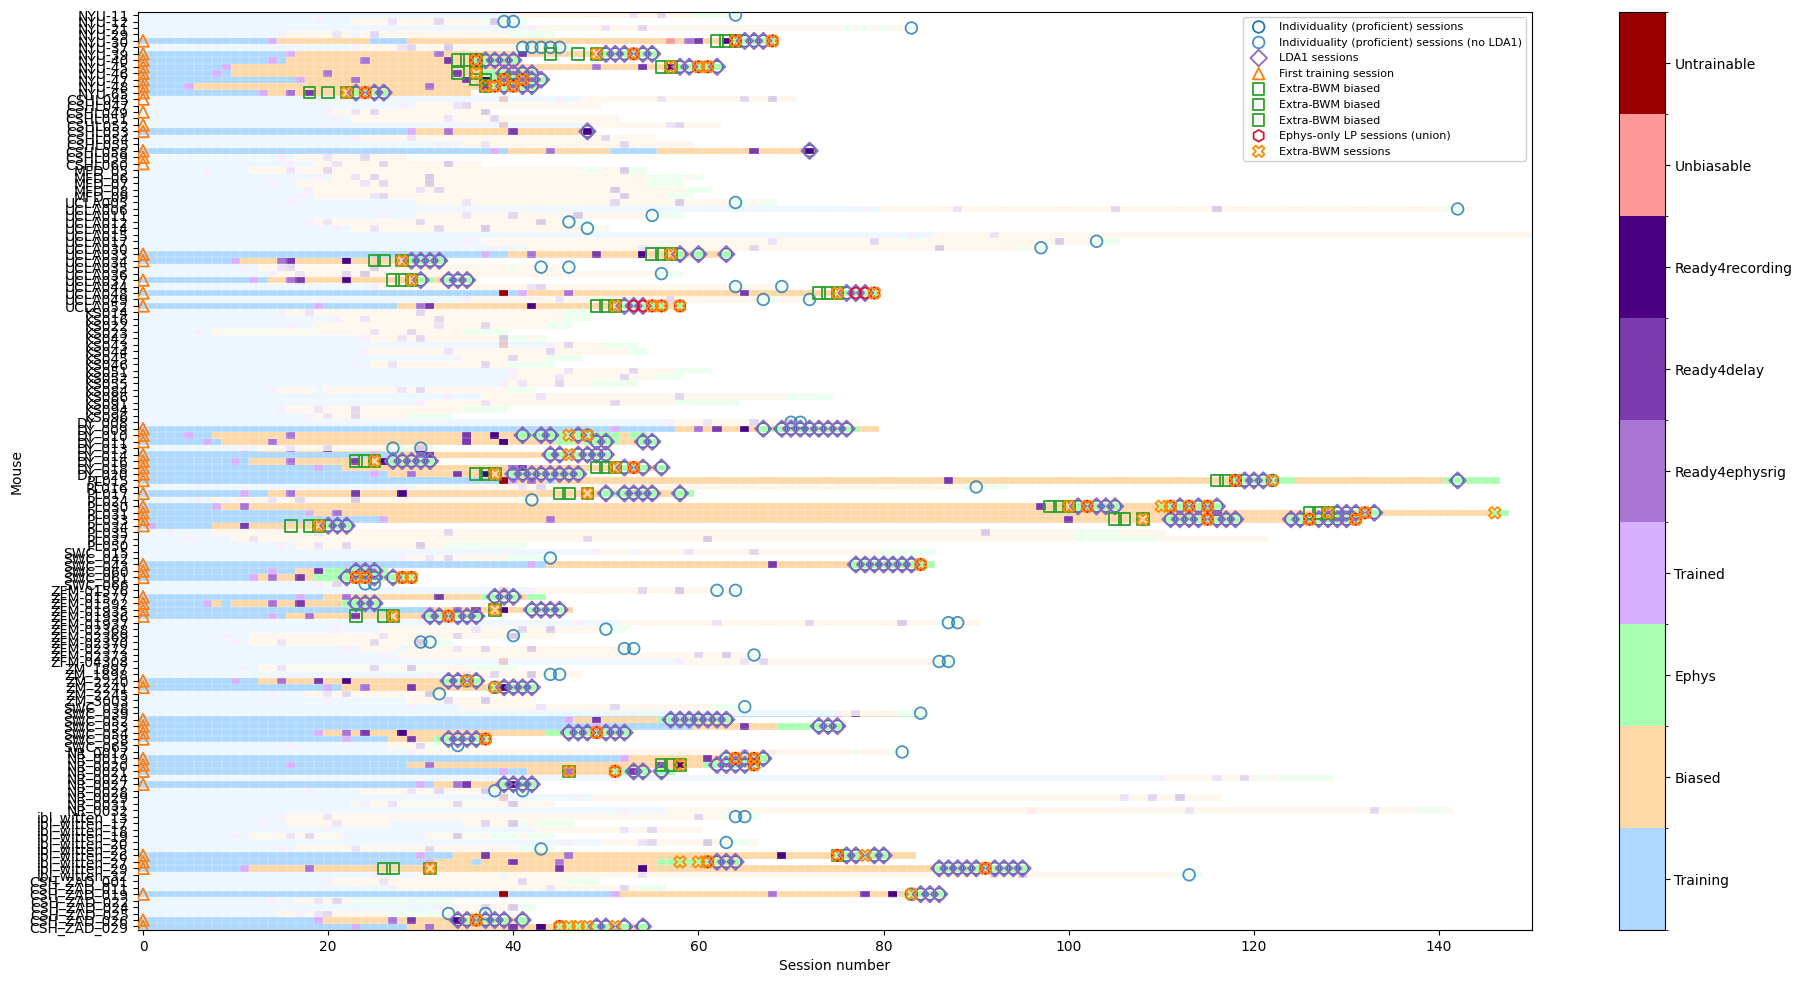

In [11]:
cmap = ListedColormap(colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5], cmap.N)

# Optionally drop non-LDA1 mice entirely instead of dimming them
plot_subjects = [s for s in subjects if s in lda1_subjects] if HIDE_NON_LDA1_MICE else list(subjects)
row_remap = {subject_row[s]: i for i, s in enumerate(plot_subjects)}
n_plot = len(plot_subjects)
max_sn_plot = int(all_sessions.loc[all_sessions['subject'].isin(plot_subjects), 'session_number'].max()) + 1
plot_matrix = np.full((n_plot, max_sn_plot), np.nan)
for i, subj in enumerate(plot_subjects):
    subj_df = all_sessions[all_sessions['subject'] == subj]
    plot_matrix[i, subj_df['session_number']] = subj_df['protocol_number']

def remap(points):
    return [(row_remap[r], sn) for r, sn in points if r in row_remap]

fig, ax = plt.subplots(figsize=(19, 0.07 * n_plot))
im = ax.imshow(plot_matrix, aspect='auto', cmap=cmap, norm=norm)
ax.set_xlabel('Session number')
ax.set_ylabel('Mouse')
ax.set_yticks(np.arange(n_plot))
ax.set_yticklabels(plot_subjects)

# Dim rows missing from the proficient pool (non-LDA1 mice are either dropped above
# via HIDE_NON_LDA1_MICE, or dimmed here alongside non-proficient ones)
for i, subj in enumerate(plot_subjects):
    if subj not in proficient_subjects or (not HIDE_NON_LDA1_MICE and subj not in lda1_subjects):
        ax.axhspan(i - 0.5, i + 0.5, color='white', alpha=NON_PROFICIENT_DIM_ALPHA, zorder=1.5, linewidth=0)

ax.set_xticks(np.arange(-0.5, plot_matrix.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, plot_matrix.shape[0], 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=0.2)
ax.tick_params(which='minor', length=0)

any_shown = False
for name, spec in LAYER_SPECS.items():
    if not SHOW_LAYERS.get(name, False):
        continue
    points = remap(spec['points'])
    if points:
        ys, xs = zip(*points)
        ax.scatter(xs, ys, marker=spec['marker'], s=70, facecolor='none', edgecolor=spec['color'],
                   linewidth=1.3, label=spec['label'], zorder=3)
        any_shown = True
    points_dim = remap(spec.get('points_dim', []))
    if points_dim:
        ys, xs = zip(*points_dim)
        ax.scatter(xs, ys, marker=spec['marker'], s=70, facecolor='none', edgecolor=spec['color'],
                   linewidth=1.3, alpha=PROFICIENT_NON_LDA1_ALPHA,
                   label=f"{spec['label']} (no LDA1)", zorder=3)
        any_shown = True

if any_shown:
    ax.legend(loc='upper right', framealpha=0.9, fontsize=8)

cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8])
cbar.ax.set_yticklabels(['Training', 'Biased', 'Ephys', 'Trained', 'Ready4ephysrig',
                         'Ready4delay', 'Ready4recording', 'Unbiasable', 'Untrainable'])

plt.xlim([-.5, 150])
plt.tight_layout()
plt.show()

## New analysis: LDA1-highlighted overview, with real LightningPose availability

Separate plot, same grid/mice/protocol colors as above, but:
- only mice with an LDA1 session are shown at full color (everyone else dimmed, same `NON_PROFICIENT_DIM_ALPHA` wash as above) — no other layer filtering
- first-training sessions (already LDA1-scoped) marked with an orange triangle
- individuality ("proficient") sessions marked with a blue circle, for any mouse (not LDA1-restricted)
- every session cell (any mouse) that **actually has LightningPose data registered on ONE** — queried live, not from any of the candidate/queued lists above — gets a black outline. One REST call per mouse (`dataset_type='camera.lightningPose'` covers left/right/body views at once), not one per session.

In [12]:
from one.api import ONE
from matplotlib.patches import Rectangle

one = ONE(base_url='https://alyx.internationalbrainlab.org', silent=True)

# One REST call per subject; dataset_type='camera.lightningPose' covers left/right/body views at once
lp_sessions_by_subject = {}
for subj in subjects:
    try:
        ds = one.alyx.rest('datasets', 'list', dataset_type='camera.lightningPose', subject=subj)
        lp_sessions_by_subject[subj] = {d['session'].rstrip('/').split('/')[-1] for d in ds}
    except Exception as err:
        print(subj, 'error:', err)
        lp_sessions_by_subject[subj] = set()

lp_all_sessions = set().union(*lp_sessions_by_subject.values()) if lp_sessions_by_subject else set()
n_lp_mice = sum(len(v) > 0 for v in lp_sessions_by_subject.values())
print(f'{len(lp_all_sessions)} sessions across {n_lp_mice} mice have LightningPose data on ONE (any camera view)')

742 sessions across 137 mice have LightningPose data on ONE (any camera view)


### Investigation: mice that appear to have only one LDA1 session

7 mice (`CSHL045`, `CSHL049`, `CSHL052`, `CSHL053`, `CSHL058`, `CSHL059`, `CSHL060`) account for all 27 "missing" `lda1` eids reported by the `locate()` diagnostics above. Checked live on Alyx: every one of these eids genuinely belongs to the right subject and exists as a real session — they're just **absent from the cached `all_session_details_bwm` table**, not from LDA1 itself.

Root cause: `all_session_details_bwm` is built from each subject's `_ibl_subjectTrials.table` aggregate (see `load_latest_working_aggregate` above). For these 7 CSHL mice specifically, the latest available aggregate revision stops short of some of their real session dates — e.g. `CSHL045`'s trials aggregate covers only up to 2020-02-21, but two of its LDA1 sessions are dated 2020-02-24 and 2020-02-27. The aggregate was simply never refreshed to include that mouse's last few sessions, while the LDA1 pipeline (which queries live per-session) saw them fine.

Practical effect before the fix below: `CSHL053` and `CSHL058` had 2/3 LDA1 sessions silently dropped (only 1 marker visible), and `CSHL045/049/052/059/060` had *all* their LDA1 sessions dropped — so those 5 mice weren't even recognized as "LDA1 mice" and were wrongly dimmed like a non-LDA1 mouse. Fixed by computing `lda1_subjects` directly from `lda1_df['mouse_name']` instead of joining through `all_sessions` (see the updated cell above). The 2 CSHL053/058 sessions missing from the cache still can't be *plotted* (no `session_number` to place them at), but the mice themselves are now correctly highlighted.

694 cells highlighted as having LightningPose data


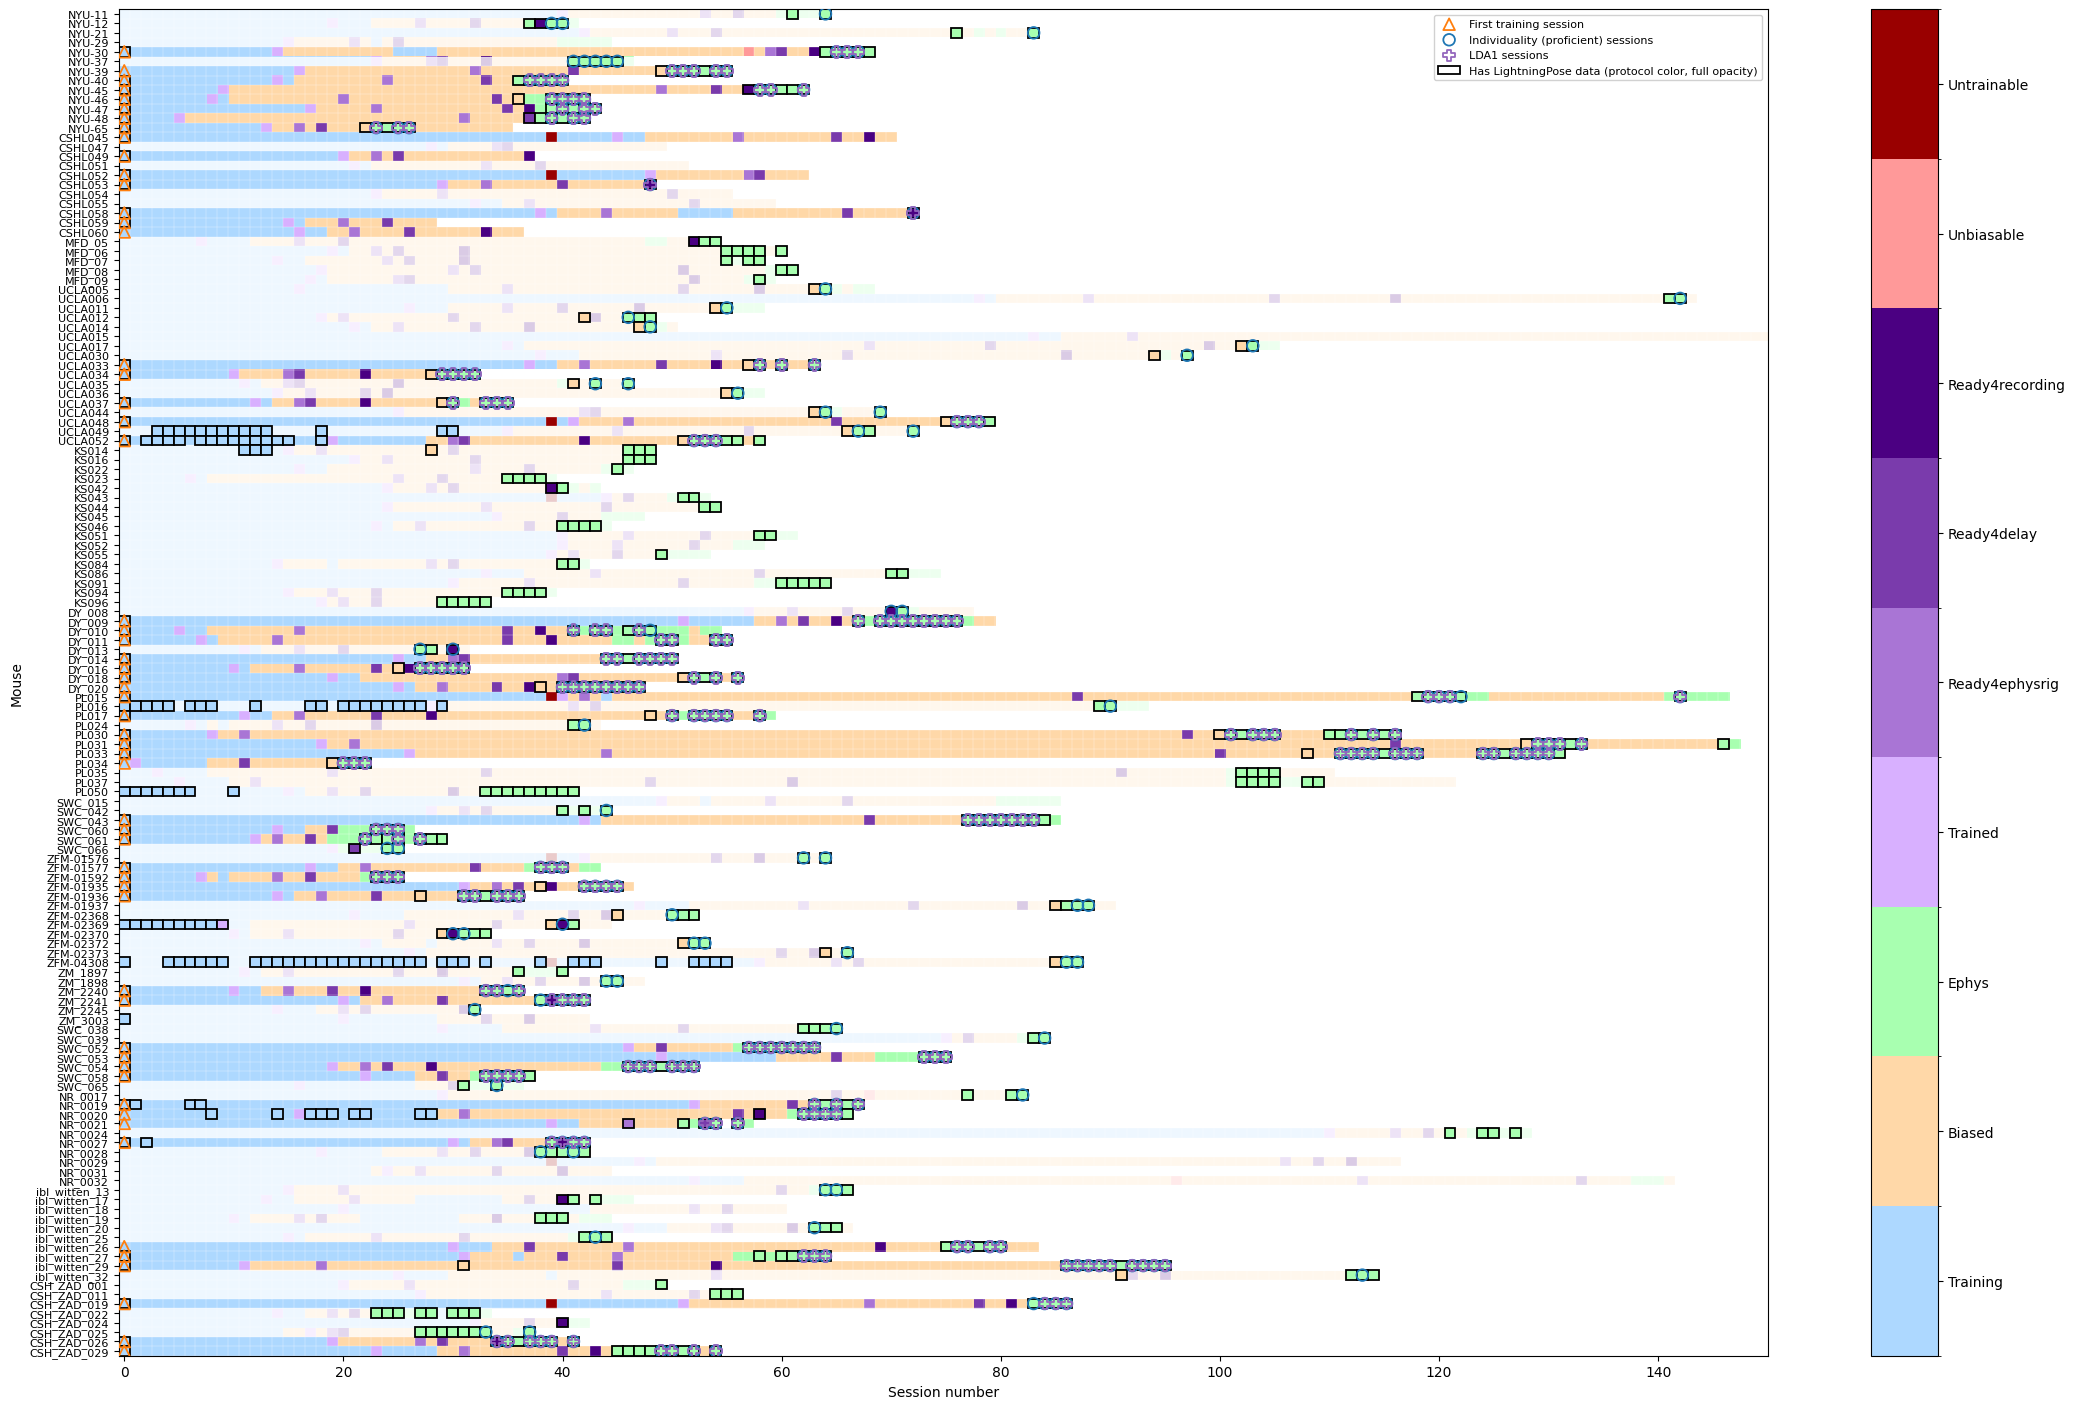

In [13]:
fig3, ax3 = plt.subplots(figsize=(22, 0.1 * n_mice))
im3 = ax3.imshow(protocol_matrix, aspect='auto', cmap=cmap, norm=norm)
ax3.set_xlabel('Session number')
ax3.set_ylabel('Mouse')
ax3.set_yticks(np.arange(n_mice))
ax3.set_yticklabels(subjects, fontsize=8)

# Highlight only mice with an LDA1 session; dim everyone else
for i, subj in enumerate(subjects):
    if subj not in lda1_subjects:
        ax3.axhspan(i - 0.5, i + 0.5, color='white', alpha=NON_PROFICIENT_DIM_ALPHA, zorder=1.5, linewidth=0)

ax3.set_xticks(np.arange(-0.5, protocol_matrix.shape[1], 1), minor=True)
ax3.set_yticks(np.arange(-0.5, protocol_matrix.shape[0], 1), minor=True)
ax3.grid(which='minor', color='white', linestyle='-', linewidth=0.2)
ax3.tick_params(which='minor', length=0)

# Highlight every session cell (any mouse) that has LightningPose data available on ONE --
# repaint it with its own protocol color at full opacity (undoing the dim wash for that one
# cell, independent of whether the mouse's row is dimmed) and add a black border to mark it.
n_outlined = 0
for subj, sess_ids in lp_sessions_by_subject.items():
    if not sess_ids or subj not in subject_row:
        continue
    row_i = subject_row[subj]
    sub_df = all_sessions[all_sessions['subject'] == subj]
    sess_nums = sub_df.loc[sub_df['session'].isin(sess_ids), 'session_number']
    for sn in sess_nums:
        protocol_value = protocol_matrix[row_i, sn]
        if np.isnan(protocol_value):
            continue
        cell_color = cmap(norm(protocol_value))
        ax3.add_patch(Rectangle((sn - 0.5, row_i - 0.5), 1, 1, fill=True,
                                 facecolor=cell_color, alpha=1.0, edgecolor='black',
                                 linewidth=1.3, zorder=2.5))
        n_outlined += 1
print(f'{n_outlined} cells highlighted as having LightningPose data')

# Mark first training session (already scoped to LDA1 mice)
points, _ = locate(training1_sessions)
if points:
    ys, xs = zip(*points)
    ax3.scatter(xs, ys, marker='^', s=70, facecolor='none', edgecolor='tab:orange',
                linewidth=1.3, label='First training session', zorder=3)

# Mark individuality (proficient) sessions -- any mouse, not LDA1-restricted
points, _ = locate(proficient_sessions)
if points:
    ys, xs = zip(*points)
    ax3.scatter(xs, ys, marker='o', s=70, facecolor='none', edgecolor='tab:blue',
                linewidth=1.3, label='Individuality (proficient) sessions', zorder=3)

# Mark the actual LDA1 sessions themselves (distinct from 'proficient' -- a highlighted
# mouse can have many LDA1 sessions but few/no proficient ones, or vice versa)
points, _ = locate(lda1_sessions)
if points:
    ys, xs = zip(*points)
    ax3.scatter(xs, ys, marker='P', s=70, facecolor='none', edgecolor='tab:purple',
                linewidth=1.3, label='LDA1 sessions', zorder=3)

lp_patch = Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='black', linewidth=1.3,
                      label='Has LightningPose data (protocol color, full opacity)')
ax3.legend(handles=ax3.get_legend_handles_labels()[0] + [lp_patch], loc='upper right',
           framealpha=0.9, fontsize=8)
cbar3 = plt.colorbar(im3, ax=ax3, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8])
cbar3.ax.set_yticklabels(['Training', 'Biased', 'Ephys', 'Trained', 'Ready4ephysrig',
                          'Ready4delay', 'Ready4recording', 'Unbiasable', 'Untrainable'])

plt.xlim([-.5, 150])
plt.tight_layout()
plt.show()

## Same plot, but non-LDA1 mice dropped entirely (not dimmed)

Identical symbols/highlighting to the plot above (first-training triangle, individuality-session circle, LDA1-session `+`, LP-availability highlight in the session's own protocol color) but the grid itself only contains the 56 LDA1 mice -- everyone else is simply not a row, rather than dimmed.

378 LP cells highlighted


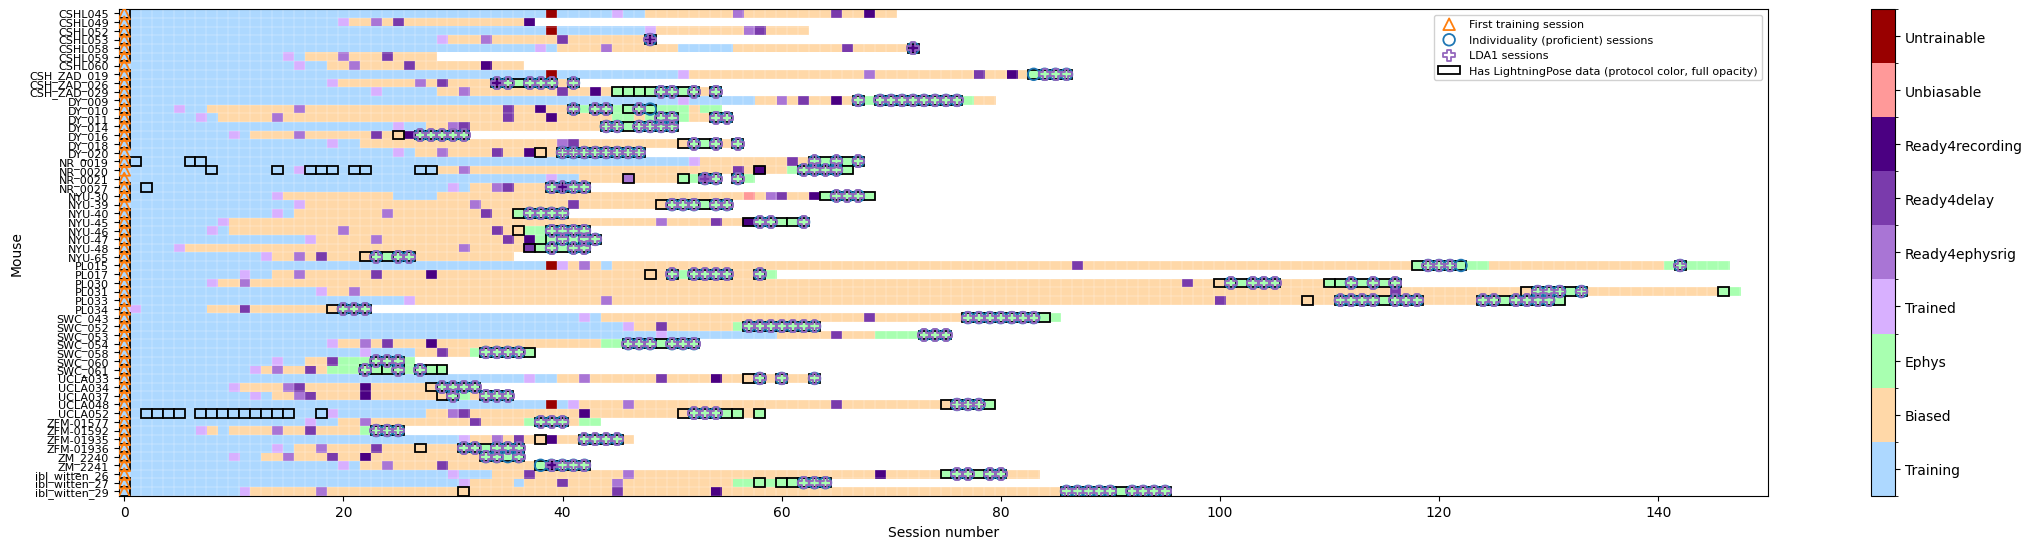

In [14]:
lda1_only_subjects = sorted(lda1_subjects)
n_l = len(lda1_only_subjects)
lda1_row = {s: i for i, s in enumerate(lda1_only_subjects)}

max_sn_l = int(all_sessions.loc[all_sessions['subject'].isin(lda1_only_subjects), 'session_number'].max()) + 1
protocol_matrix_l = np.full((n_l, max_sn_l), np.nan)
for s in lda1_only_subjects:
    subj_df = all_sessions[all_sessions['subject'] == s]
    protocol_matrix_l[lda1_row[s], subj_df['session_number']] = subj_df['protocol_number']

def locate_in(eids, row_map):
    points = []
    for eid in eids:
        if eid in lookup.index:
            row = lookup.loc[eid]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            subj = row['subject']
            if subj in row_map:
                points.append((row_map[subj], row['session_number']))
    return points

fig6, ax6 = plt.subplots(figsize=(22, 0.1 * n_l))
im6 = ax6.imshow(protocol_matrix_l, aspect='auto', cmap=cmap, norm=norm)
ax6.set_xlabel('Session number')
ax6.set_ylabel('Mouse')
ax6.set_yticks(np.arange(n_l))
ax6.set_yticklabels(lda1_only_subjects, fontsize=8)
ax6.set_xticks(np.arange(-0.5, protocol_matrix_l.shape[1], 1), minor=True)
ax6.set_yticks(np.arange(-0.5, protocol_matrix_l.shape[0], 1), minor=True)
ax6.grid(which='minor', color='white', linestyle='-', linewidth=0.2)
ax6.tick_params(which='minor', length=0)

# LP-availability highlight: protocol color, full opacity, black border
n_lp = 0
for s in lda1_only_subjects:
    sess_ids = lp_sessions_by_subject.get(s, set())
    if not sess_ids:
        continue
    row_i = lda1_row[s]
    sub_df = all_sessions[all_sessions['subject'] == s]
    sess_nums = sub_df.loc[sub_df['session'].isin(sess_ids), 'session_number']
    for sn in sess_nums:
        val = protocol_matrix_l[row_i, sn]
        if np.isnan(val):
            continue
        ax6.add_patch(Rectangle((sn - 0.5, row_i - 0.5), 1, 1, fill=True,
                                 facecolor=cmap(norm(val)), alpha=1.0, edgecolor='black',
                                 linewidth=1.3, zorder=2.5))
        n_lp += 1
print(f'{n_lp} LP cells highlighted')

points = locate_in(training1_sessions, lda1_row)
if points:
    ys, xs = zip(*points)
    ax6.scatter(xs, ys, marker='^', s=70, facecolor='none', edgecolor='tab:orange',
                linewidth=1.3, label='First training session', zorder=3)

points = locate_in(proficient_sessions, lda1_row)
if points:
    ys, xs = zip(*points)
    ax6.scatter(xs, ys, marker='o', s=70, facecolor='none', edgecolor='tab:blue',
                linewidth=1.3, label='Individuality (proficient) sessions', zorder=3)

points = locate_in(lda1_sessions, lda1_row)
if points:
    ys, xs = zip(*points)
    ax6.scatter(xs, ys, marker='P', s=70, facecolor='none', edgecolor='tab:purple',
                linewidth=1.3, label='LDA1 sessions', zorder=3)

lp_patch = Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='black', linewidth=1.3,
                      label='Has LightningPose data (protocol color, full opacity)')
ax6.legend(handles=ax6.get_legend_handles_labels()[0] + [lp_patch], loc='upper right',
           framealpha=0.9, fontsize=8)
cbar6 = plt.colorbar(im6, ax=ax6, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8])
cbar6.ax.set_yticklabels(['Training', 'Biased', 'Ephys', 'Trained', 'Ready4ephysrig',
                          'Ready4delay', 'Ready4recording', 'Unbiasable', 'Untrainable'])

plt.xlim([-.5, 150])
plt.tight_layout()
plt.show()

## New analysis: why isn't LDA1 using more sessions?

Restricting to mice with **3 or more ephys-protocol sessions that have LightningPose data** (the same bar LDA1 itself clears -- recall every LDA1 mouse has >=3 sessions). For those mice's qualifying ephys+LP sessions specifically: border is **black** if the session is already in the LDA1 dataset, **red** if it isn't. Everything else with LP (any protocol, any mouse) still gets a thin black border as before, for context.

The grid below is restricted to just the qualifying mice (readability), not all 142.

In [15]:
lda1_sessions_set = set(lda1_sessions)

# Ephys+LP sessions per mouse (any mouse with LP data at all, not just LDA1/highlighted ones)
ephys_lp_by_subject = {}
for subj, sess_ids in lp_sessions_by_subject.items():
    if not sess_ids:
        continue
    protos = task_protocol_lookup.reindex(list(sess_ids))
    ephys_ids = protos[protos.str.contains('ephys', na=False)].index.tolist()
    if ephys_ids:
        ephys_lp_by_subject[subj] = ephys_ids

# Mice clearing the same >=3-session bar LDA1 itself uses
qualifying = {s: ids for s, ids in ephys_lp_by_subject.items() if len(ids) >= 3}
qualifying_subjects = sorted(qualifying.keys())

not_in_lda1 = [(s, eid) for s, ids in qualifying.items() for eid in ids if eid not in lda1_sessions_set]
in_lda1 = [(s, eid) for s, ids in qualifying.items() for eid in ids if eid in lda1_sessions_set]
zero_overlap_mice = [s for s in qualifying_subjects if s not in lda1_subjects]

print(f'{len(qualifying_subjects)} mice have >=3 ephys+LP sessions (LDA1 uses {len(lda1_subjects)} mice total)')
print(f'{len(in_lda1)} of their ephys+LP sessions ARE already in LDA1')
print(f'{len(not_in_lda1)} of their ephys+LP sessions are NOT in LDA1 (red border below)')
print(f'{len(zero_overlap_mice)} qualifying mice have ZERO presence in LDA1 at all: {zero_overlap_mice}')

85 mice have >=3 ephys+LP sessions (LDA1 uses 56 mice total)
219 of their ephys+LP sessions ARE already in LDA1
203 of their ephys+LP sessions are NOT in LDA1 (red border below)
36 qualifying mice have ZERO presence in LDA1 at all: ['CSH_ZAD_011', 'CSH_ZAD_022', 'CSH_ZAD_025', 'DY_013', 'KS014', 'KS016', 'KS023', 'KS046', 'KS091', 'KS094', 'KS096', 'MFD_05', 'MFD_06', 'MFD_07', 'NR_0017', 'NR_0024', 'NR_0028', 'NYU-12', 'NYU-37', 'PL035', 'PL037', 'PL050', 'SWC_038', 'SWC_042', 'SWC_066', 'UCLA012', 'UCLA049', 'ZFM-01937', 'ZFM-02368', 'ZFM-02370', 'ibl_witten_13', 'ibl_witten_17', 'ibl_witten_19', 'ibl_witten_20', 'ibl_witten_25', 'ibl_witten_32']


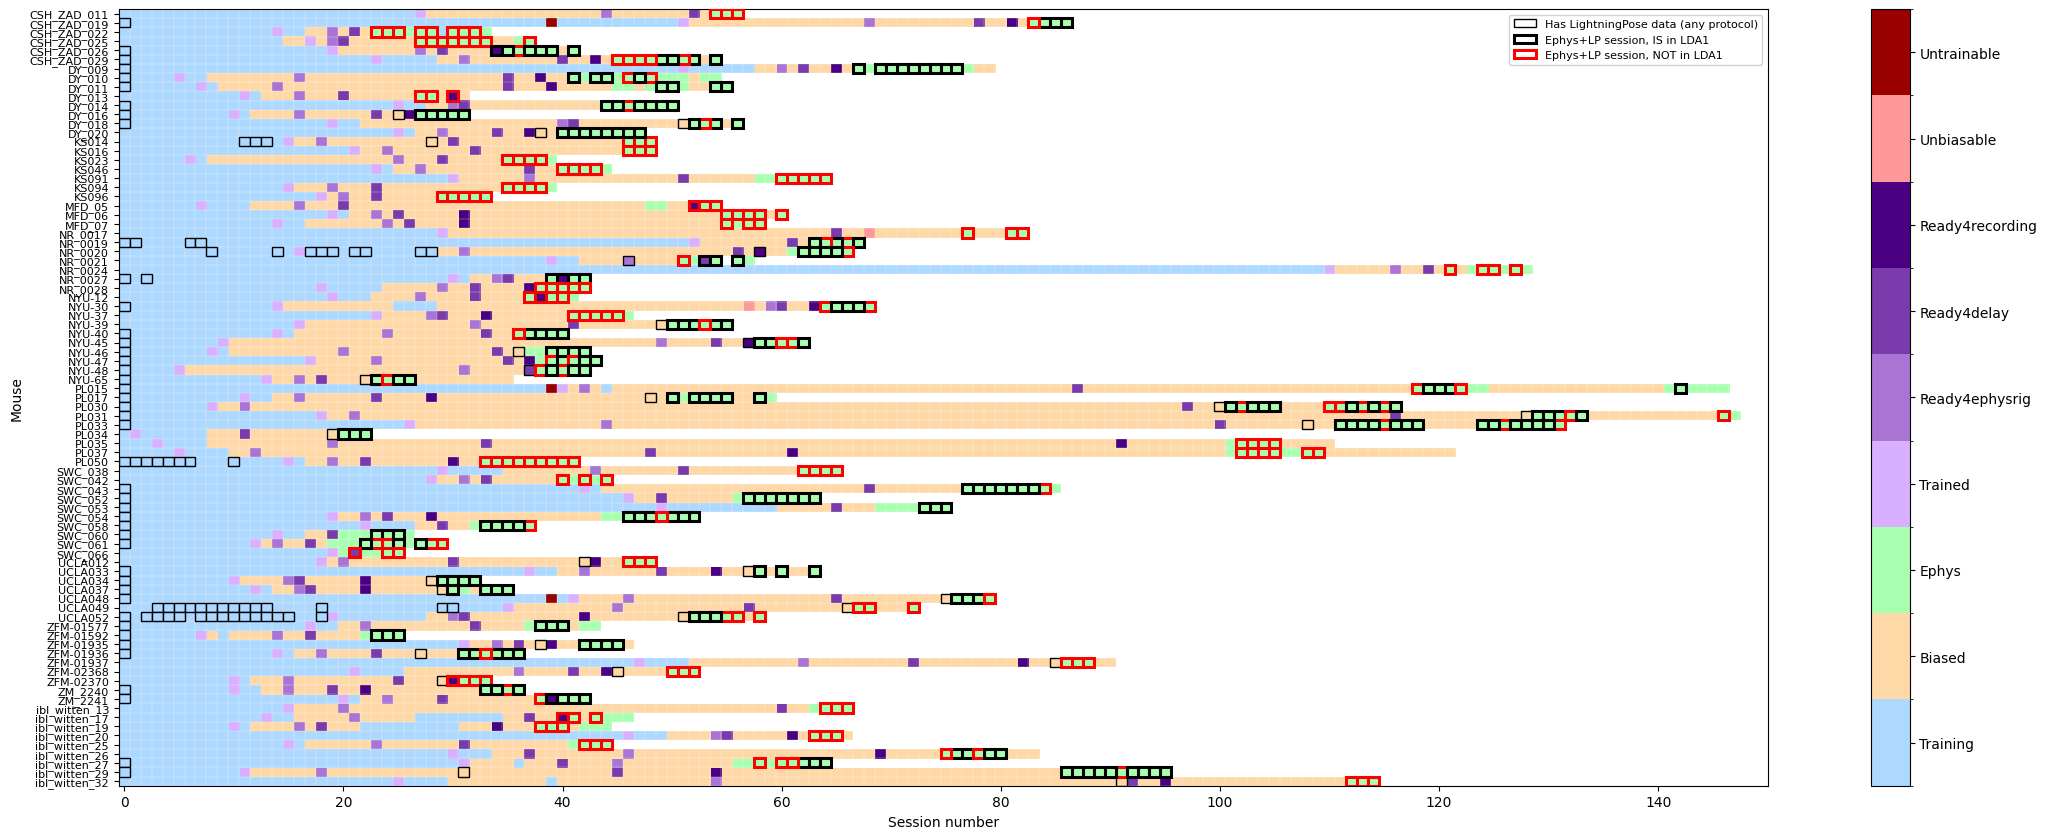

In [16]:
qual_row = {s: i for i, s in enumerate(qualifying_subjects)}
n_qual = len(qualifying_subjects)

max_sn_q = int(all_sessions.loc[all_sessions['subject'].isin(qualifying_subjects), 'session_number'].max()) + 1
protocol_matrix_q = np.full((n_qual, max_sn_q), np.nan)
for s in qualifying_subjects:
    subj_df = all_sessions[all_sessions['subject'] == s]
    protocol_matrix_q[qual_row[s], subj_df['session_number']] = subj_df['protocol_number']

fig4, ax4 = plt.subplots(figsize=(22, 0.1 * n_qual))
im4 = ax4.imshow(protocol_matrix_q, aspect='auto', cmap=cmap, norm=norm)
ax4.set_xlabel('Session number')
ax4.set_ylabel('Mouse')
ax4.set_yticks(np.arange(n_qual))
ax4.set_yticklabels(qualifying_subjects, fontsize=8)
ax4.set_xticks(np.arange(-0.5, protocol_matrix_q.shape[1], 1), minor=True)
ax4.set_yticks(np.arange(-0.5, protocol_matrix_q.shape[0], 1), minor=True)
ax4.grid(which='minor', color='white', linestyle='-', linewidth=0.2)
ax4.tick_params(which='minor', length=0)

# 1. Every session with LP data (any protocol) -> protocol-color fill, thin black border
for s in qualifying_subjects:
    sess_ids = lp_sessions_by_subject.get(s, set())
    if not sess_ids:
        continue
    row_i = qual_row[s]
    sub_df = all_sessions[all_sessions['subject'] == s]
    sess_nums = sub_df.loc[sub_df['session'].isin(sess_ids), 'session_number']
    for sn in sess_nums:
        val = protocol_matrix_q[row_i, sn]
        if np.isnan(val):
            continue
        ax4.add_patch(Rectangle((sn - 0.5, row_i - 0.5), 1, 1, fill=True,
                                 facecolor=cmap(norm(val)), alpha=1.0, edgecolor='black',
                                 linewidth=1.0, zorder=2.5))

# 2+3. Ephys+LP sessions of qualifying mice -> thicker border, red if NOT in LDA1, black if it IS
for s, eids in qualifying.items():
    row_i = qual_row[s]
    sub_df = all_sessions[all_sessions['subject'] == s]
    for eid in eids:
        match = sub_df.loc[sub_df['session'] == eid, 'session_number']
        if match.empty:
            continue
        sn = match.iloc[0]
        val = protocol_matrix_q[row_i, sn]
        if np.isnan(val):
            continue
        edge = 'black' if eid in lda1_sessions_set else 'red'
        ax4.add_patch(Rectangle((sn - 0.5, row_i - 0.5), 1, 1, fill=True,
                                 facecolor=cmap(norm(val)), alpha=1.0, edgecolor=edge,
                                 linewidth=2.2, zorder=3))

black_patch = Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='black', linewidth=2.2,
                         label='Ephys+LP session, IS in LDA1')
red_patch = Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='red', linewidth=2.2,
                       label='Ephys+LP session, NOT in LDA1')
thin_patch = Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='black', linewidth=1.0,
                        label='Has LightningPose data (any protocol)')
ax4.legend(handles=[thin_patch, black_patch, red_patch], loc='upper right', framealpha=0.9, fontsize=8)

cbar4 = plt.colorbar(im4, ax=ax4, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8])
cbar4.ax.set_yticklabels(['Training', 'Biased', 'Ephys', 'Trained', 'Ready4ephysrig',
                          'Ready4delay', 'Ready4recording', 'Unbiasable', 'Untrainable'])
plt.xlim([-.5, 150])
plt.tight_layout()
plt.show()

### Investigation: do the red-border sessions fail task/video QC on left or right camera?

For each of the 203 red-border sessions, pull `extended_qc` from Alyx and check: overall task QC, overall behavior QC, and the overall video/DLC/LightningPose verdicts for left and right camera separately. One REST call per session (~2-3 min to run live).

In [17]:
qc_rows = []
for subj, eid in not_in_lda1:
    try:
        det = one.get_details(eid, full=True)
        ext = det.get('extended_qc', {}) or {}
        qc_rows.append({
            'subject': subj, 'eid': eid, 'session_qc': det.get('qc'),
            'task': ext.get('task'), 'behavior': ext.get('behavior'),
            'videoLeft': ext.get('videoLeft'), 'videoRight': ext.get('videoRight'),
            'dlcLeft': ext.get('dlcLeft'), 'dlcRight': ext.get('dlcRight'),
            'lightningPoseLeft': ext.get('lightningPoseLeft'), 'lightningPoseRight': ext.get('lightningPoseRight'),
        })
    except Exception as err:
        qc_rows.append({'subject': subj, 'eid': eid, 'error': str(err)})

red_qc = pd.DataFrame(qc_rows)
red_qc['mouse_never_in_lda1'] = ~red_qc['subject'].isin(lda1_subjects)
print(red_qc.shape)

(203, 12)


In [18]:
qc_fields = ['task', 'behavior', 'videoLeft', 'videoRight', 'lightningPoseLeft', 'lightningPoseRight']

print('=== Sessions from mice ALREADY in LDA1 (this particular session just wasn\'t picked) ===')
some_overlap = red_qc[~red_qc['mouse_never_in_lda1']]
print(f'n = {len(some_overlap)}')
for f in qc_fields:
    print(f, dict(some_overlap[f].value_counts(dropna=False)))

print()
print('=== Sessions from mice with ZERO presence in LDA1 (mouse never included at all) ===')
zero_overlap = red_qc[red_qc['mouse_never_in_lda1']]
print(f'n = {len(zero_overlap)}')
for f in qc_fields:
    print(f, dict(zero_overlap[f].value_counts(dropna=False)))

# QC-clean = video not FAIL/CRITICAL on either camera, behavior QC pass, LP pass-or-absent
def reasonably_clean(row):
    ok_video = row['videoLeft'] in ('PASS', 'WARNING') and row['videoRight'] in ('PASS', 'WARNING')
    ok_behavior = row['behavior'] == 1
    ok_lp = (pd.isna(row['lightningPoseLeft']) or row['lightningPoseLeft'] == 'PASS') and \
            (pd.isna(row['lightningPoseRight']) or row['lightningPoseRight'] == 'PASS')
    return ok_video and ok_behavior and ok_lp

zero_overlap = zero_overlap.copy()
zero_overlap['reasonably_clean'] = zero_overlap.apply(reasonably_clean, axis=1)
n_clean_mice = zero_overlap.loc[zero_overlap['reasonably_clean'], 'subject'].nunique()
print()
print(f"{zero_overlap['reasonably_clean'].sum()}/{len(zero_overlap)} never-included-mouse sessions look QC-clean "
      f'(video L+R not FAIL/CRITICAL, behavior PASS, LP PASS-or-absent), across {n_clean_mice} distinct mice')

still_qualifying = zero_overlap[zero_overlap['reasonably_clean']].groupby('subject').size()
still_qualifying = still_qualifying[still_qualifying >= 3]
print(f'{len(still_qualifying)} never-included mice still clear the >=3-session bar using only QC-clean sessions:')
print(still_qualifying.sort_values(ascending=False))

=== Sessions from mice ALREADY in LDA1 (this particular session just wasn't picked) ===
n = 58
task {'WARNING': np.int64(53), 'FAIL': np.int64(4), 'PASS': np.int64(1)}
behavior {0: np.int64(29), 1: np.int64(29)}
videoLeft {'WARNING': np.int64(33), 'FAIL': np.int64(13), 'PASS': np.int64(11), 'CRITICAL': np.int64(1)}
videoRight {'WARNING': np.int64(37), 'FAIL': np.int64(10), 'PASS': np.int64(10), 'CRITICAL': np.int64(1)}
lightningPoseLeft {'PASS': np.int64(47), 'FAIL': np.int64(10), None: np.int64(1)}
lightningPoseRight {'PASS': np.int64(54), 'FAIL': np.int64(3), None: np.int64(1)}

=== Sessions from mice with ZERO presence in LDA1 (mouse never included at all) ===
n = 145
task {'WARNING': np.int64(106), 'FAIL': np.int64(20), 'PASS': np.int64(19)}
behavior {1: np.int64(134), 0: np.int64(11)}
videoLeft {'WARNING': np.int64(60), 'PASS': np.int64(41), 'FAIL': np.int64(31), 'CRITICAL': np.int64(13)}
videoRight {'WARNING': np.int64(60), 'PASS': np.int64(43), 'FAIL': np.int64(26), 'CRITICAL': 

### Conclusion

The 203 red-border sessions split into two very different stories:

1. **58 sessions belong to mice already in LDA1** (just not this particular session). Here QC looks like a real, deliberate filter: `behavior` is roughly 50/50 PASS/FAIL (vs. ~92% PASS in the other group) — i.e. within a mouse that's already included, sessions that fail behavior QC are the ones being skipped. That's expected, sensible session-level filtering, not a gap.

2. **145 sessions belong to 36 mice with *zero* presence in LDA1 at all.** Here QC does *not* look like the explanation: `behavior` is PASS for 92% of them, and most video/LightningPose fields are PASS or just WARNING (not FAIL/CRITICAL). After requiring video (L+R) to be at least WARNING, behavior PASS, and LP PASS-or-absent, **70/145 sessions across 23 mice still look QC-clean**, and **12 of those mice still clear the same >=3-session bar** using only the clean sessions (`KS014, KS016, KS023, KS046, KS096, NR_0024, NR_0028, PL035, PL037, PL050, ZFM-01937, ibl_witten_20`).

So the main reason more sessions/mice aren't in LDA1 doesn't look like a QC problem you're missing — it looks like these 36 mice (several whole labs: KS0xx, MFD_0x, most `ibl_witten_*`, several `CSH_ZAD_*`) were simply never added to the LDA1 mouse cohort, independent of data quality. The 12 mice above are the most immediate, QC-clean candidates for inclusion if you want to expand the analysis.

### Follow-up: did the never-included mice actually have valid recordings/insertions?

Video/behavior QC being clean doesn't rule out a *recording* problem -- checking for each of the 145 never-included-mouse sessions whether it has a registered probe insertion at all, whether that insertion has resolved alignment, and whether either the session or an insertion is flagged CRITICAL (same criteria used earlier in this notebook for the base BWM query).

In [19]:
zero_overlap_pairs = [(s, eid) for s in zero_overlap_mice for eid in qualifying[s]]

ins_rows = []
for subj, eid in zero_overlap_pairs:
    try:
        ins = one.alyx.rest('insertions', 'list', session=eid, no_cache=True)
        alignment_counts = [((i.get('json') or {}).get('extended_qc', {}) or {}).get('alignment_count') for i in ins]
        insertion_json_qc = [(i.get('json') or {}).get('qc') for i in ins]
        det = one.get_details(eid, full=True)
        ins_rows.append({
            'subject': subj, 'eid': eid, 'n_insertions': len(ins),
            'session_qc': det.get('qc'),
            'has_resolved_alignment': any((c is not None and c > 0) for c in alignment_counts),
            'has_critical_insertion_qc': any(q == 'CRITICAL' for q in insertion_json_qc),
        })
    except Exception as err:
        ins_rows.append({'subject': subj, 'eid': eid, 'error': str(err)})

ins_df = pd.DataFrame(ins_rows)
no_insertion = ins_df[ins_df['n_insertions'] == 0]
has_ins = ins_df[ins_df['n_insertions'] > 0].copy()
has_ins['recording_clean'] = (has_ins['has_resolved_alignment'] & ~has_ins['has_critical_insertion_qc']
                               & (has_ins['session_qc'] != 'CRITICAL'))

print(f'{len(no_insertion)}/{len(ins_df)} sessions have ZERO registered probe insertions '
      f'(mice: {sorted(no_insertion["subject"].unique())})')
print(f'{(~has_ins["has_resolved_alignment"]).sum()}/{len(has_ins)} of the rest have NO resolved alignment on any insertion')
print(f'{has_ins["has_critical_insertion_qc"].sum()}/{len(has_ins)} have an insertion flagged CRITICAL')
print(f'{(has_ins["session_qc"]=="CRITICAL").sum()}/{len(has_ins)} have session-level QC == CRITICAL')
print(f'{has_ins["recording_clean"].sum()}/{len(has_ins)} sessions (with an insertion) look fully clean on recording/insertion QC too')

# Do the 12 QC-clean candidate mice specifically have valid insertions on every qualifying session?
candidate_mice = still_qualifying.index.tolist()
candidate_check = ins_df[ins_df['subject'].isin(candidate_mice)]
print()
print('Insertions per session for the 12 QC-clean candidate mice (min/max, any zero?):')
print(candidate_check.groupby('subject')['n_insertions'].agg(['count', 'min', 'max']))
print('Any zero-insertion sessions among them:', (candidate_check['n_insertions'] == 0).sum())

1/145 sessions have ZERO registered probe insertions (mice: ['SWC_066'])
7/144 of the rest have NO resolved alignment on any insertion
20/144 have an insertion flagged CRITICAL
0/144 have session-level QC == CRITICAL
119/144 sessions (with an insertion) look fully clean on recording/insertion QC too

Insertions per session for the 12 QC-clean candidate mice (min/max, any zero?):
               count  min  max
subject                       
KS014              3    1    2
KS016              3    2    2
KS023              4    2    2
KS046              4    2    2
KS096              5    1    2
NR_0024            4    1    2
NR_0028            5    1    2
PL035              4    1    1
PL037              6    1    1
PL050              9    1    2
ZFM-01937          3    1    1
ibl_witten_20      3    1    2
Any zero-insertion sessions among them: 0


**Answer: no, invalid/missing recordings are not the reason.** Of the 145 sessions from the 36 never-included mice, only **1** (`SWC_066`) has zero registered probe insertions; the other 144 all have 1-2 real insertions. Of those, ~95% have resolved alignment, none have session-level QC == CRITICAL, and the large majority are clean on insertion QC too. The 12 QC-clean candidate mice from above have a valid insertion (1-2) on every one of their qualifying sessions -- zero missing recordings among them.

So across every angle checked here (video, behavior, LightningPose, task, and now recording/insertion validity), these 36 mice don't show a data-quality reason for being absent from LDA1 -- it really does look like a coverage gap (mice/labs never added to the cohort) rather than a QC-driven exclusion.